In [1]:
from mpramnist.Sahu2022 import SahuDataset
from mpramnist.Sahu2022 import LitModel_Sahu
from mpramnist.Sahu2022 import LitModel_Sahu_binary_legnet

from mpramnist.models import HumanLegNet
from mpramnist.models import initialize_weights

from mpramnist import transforms as t

import numpy as np
import torch
import torch.nn as nn
import torch.utils.data as data

import lightning.pytorch as L
from torch.nn import functional as F

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
)
import matplotlib.pyplot as plt

def plot_pr_auc(model, trainer, loader, figsize=(4, 3)):
    """
    Plot Precision-Recall curve and compute PR-AUC metrics.

    Args:
        model: Trained PyTorch model
        loader: DataLoader with test/validation data
        threshold: Decision threshold for precision/recall calculation
        figsize: Size of the output figure
    """
    sigmoid = nn.Sigmoid()

    # Get predictions
    predictions = trainer.predict(model, dataloaders=loader)

    # Get logits
    logits = torch.cat([pred["predicted"] for pred in predictions]).cpu()
    targets = torch.cat([pred["target"] for pred in predictions]).cpu()

    # Turn to probabilities
    y_scores = sigmoid(logits).numpy()  # probabilities [0, 1]
    y_true = targets.numpy()

    # Diagnostic info
    print(f"Class distribution: {np.unique(y_true, return_counts=True)}")
    print(f"Score range after sigmoid: [{y_scores.min():.3f}, {y_scores.max():.3f}]")

    # Calculate metrics
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    avg_precision = average_precision_score(y_true, y_scores)

    # Plot with more detail
    plt.figure(figsize=figsize)
    plt.plot(recall, precision, label=f"PR Curve (AP={avg_precision:.3f})", linewidth=2)

    # Add baseline (random classifier)
    positive_ratio = y_true.mean()
    plt.axhline(
        y=positive_ratio,
        color="r",
        linestyle="--",
        label=f"Random (AP={positive_ratio:.2f})",
    )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Tasks

In [2]:
tasks = [
    "RandomEnhancer",  # 0
    "GenomicPromoter",  # 1
    "CapturePromoter",  # 2
    "GenomicEnhancer",  # 3
    "AtacSeq",  # 4
    "Binary",  # 5
]

# Random Enhancer

In [3]:
BATCH_SIZE = 1024
NUM_WORKERS = 16
train_transform = t.Compose([t.Seq2Tensor()])
val_test_transform = t.Compose([t.Seq2Tensor()])
task = "RandomEnhancer"

train_dataset = SahuDataset(task=task, split="train", transform=train_transform, root="../data")
val_dataset = SahuDataset(task=task, split="val", transform=val_test_transform, root="../data")
test_dataset = SahuDataset(task=task, split="test", transform=val_test_transform, root="../data")

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(len(train_dataset), len(val_dataset), len(test_dataset))

7942528 1985634 3309387


Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loading `train_dataloader` to estimate number of stepping batches.


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No negative samples in targets, false positive value should be meaningless. Returning zero tensor in false positive score
  warnings.warn(*args, **kwargs)


Epoch 0: 100%|██████████| 7757/7757 [36:49<00:00,  3.51it/s, v_num=129, train_loss_step=0.667]

/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)
/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples found in target, recall is undefined. Setting recall to one for all thresholds.
  warnings.warn(*args, **kwargs)


...

Epoch 0: 100%|██████████| 7757/7757 [41:53<00:00,  3.09it/s, v_num=129, train_loss_step=0.667, val_loss=0.673, val_aupr=0.597, val_auroc=0.582, train_loss_epoch=0.677]


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Testing DataLoader 0: 100%|██████████| 3232/3232 [10:29<00:00,  5.14it/s]
-----------------------------------------------------------------------------------------------------
| Test Acc: 0.552398681640625 | Test AUROC: 0.5824795961380005 | Test AUPR: 0.5976711511611938 |
| Test Precision: 0.5577383041381836 | Test Recall: 0.5061573386192322 | Test F1: 0.5306974053382874 
-----------------------------------------------------------------------------------------------------

Testing DataLoader 0: 100%|██████████| 3232/3232 [10:29<00:00,  5.14it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_aupr           0.5976711511611938
       test_auroc           0.5824795961380005
        test_loss           0.6724740266799927
─────────────────────

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Predicting DataLoader 0: 100%|██████████| 3232/3232 [04:29<00:00, 12.00it/s]
Class distribution: (array([0., 1.], dtype=float32), array([1654694, 1654693]))
Score range after sigmoid: [0.045, 1.000]


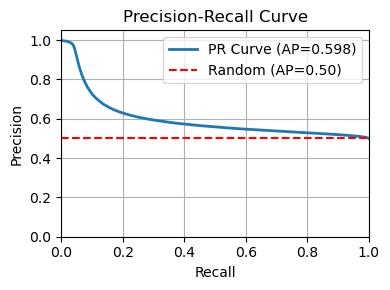

In [4]:
in_channels = 4

model = HumanLegNet(
    in_ch=in_channels,
    output_dim=1,
    stem_ch=64,
    stem_ks=11,
    ef_ks=9,
    ef_block_sizes=[32, 64, 128, 128, 256, 512, 256],
    pool_sizes=[1, 2, 1, 2, 1, 2, 1],
    resize_factor=4,
)
model.apply(initialize_weights)

seq_model = LitModel_Sahu(model=model,loss=torch.nn.BCEWithLogitsLoss(),weight_decay=1e-1,lr=1e-3,print_each=2,)

# Initialize a trainer
trainer = L.Trainer(
    accelerator="gpu",
    devices=[0],
    max_epochs=1,
    gradient_clip_val=1,
    precision="16-mixed",
    enable_progress_bar=True,
    enable_model_summary=False,
)
# Train the model
trainer.fit(seq_model, train_dataloaders=train_loader, val_dataloaders=val_loader)
trainer.test(seq_model, dataloaders=test_loader)
plot_pr_auc(seq_model, trainer, test_loader)

# Genomic promoter

In [5]:
BATCH_SIZE = 128
NUM_WORKERS = 16

train_transform = t.Compose([t.ReverseComplement(0.5),t.Seq2Tensor(),])
val_test_transform = t.Compose([t.Seq2Tensor()])

task = "genomicpromoter"
train_dataset = SahuDataset(task=task, split="train", transform=train_transform, root="../data/")
val_dataset = SahuDataset(task=task, split="val", transform=val_test_transform, root="../data/")
test_dataset = SahuDataset(task=task, split="test", transform=val_test_transform, root="../data/")

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(len(train_dataset), len(val_dataset), len(test_dataset))

36898 4098 7285


Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loading `train_dataloader` to estimate number of stepping batches.


Epoch 0: 100%|██████████| 289/289 [00:10<00:00, 27.65it/s, v_num=131, train_loss_step=0.321]

/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No negative samples in targets, false positive value should be meaningless. Returning zero tensor in false positive score
  warnings.warn(*args, **kwargs)


/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)
/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples found in target, recall is undefined. Setting recall to one for all thresholds.
  warnings.warn(*args, **kwargs)


Epoch 0: 100%|██████████| 289/289 [00:12<00:00, 23.65it/s, v_num=131, train_loss_step=0.321, val_loss=0.301, val_aupr=0.950, val_auroc=0.943, train_loss_epoch=0.362]

...

Epoch 0: 100%|██████████| 289/289 [00:13<00:00, 21.65it/s, v_num=131, train_loss_step=0.321, val_loss=0.301, val_aupr=0.950, val_auroc=0.943, train_loss_epoch=0.362]


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Testing DataLoader 0: 100%|██████████| 57/57 [00:01<00:00, 56.38it/s]
-----------------------------------------------------------------------------------------------------
| Test Acc: 0.8595744967460632 | Test AUROC: 0.933462917804718 | Test AUPR: 0.9446966648101807 |
| Test Precision: 0.9200385212898254 | Test Recall: 0.7873042225837708 | Test F1: 0.8485117554664612 
-----------------------------------------------------------------------------------------------------

Testing DataLoader 0: 100%|██████████| 57/57 [00:01<00:00, 55.91it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_aupr           0.9446966648101807
       test_auroc            0.933462917804718
        test_loss            0.319749116897583
─────────────────────────────

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Predicting DataLoader 0: 100%|██████████| 57/57 [00:00<00:00, 95.40it/s]
Class distribution: (array([0., 1.], dtype=float32), array([3646, 3639]))
Score range after sigmoid: [0.004, 0.999]


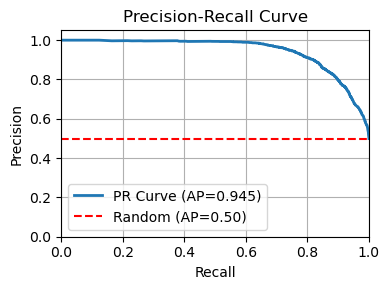

In [7]:
in_channels = 4

model = HumanLegNet(
    in_ch=in_channels,
    output_dim=1,
    stem_ch=64,
    stem_ks=11,
    ef_ks=9,
    ef_block_sizes=[32, 64, 128, 128, 256, 512, 256],
    pool_sizes=[1, 2, 1, 2, 1, 2, 1],
    resize_factor=4,
)
model.apply(initialize_weights)

seq_model = LitModel_Sahu(model=model,loss=torch.nn.BCEWithLogitsLoss(),weight_decay=1e-1,lr=1e-3,print_each=10,)

# Initialize a trainer
trainer = L.Trainer(
    accelerator="gpu",
    devices=[0],
    max_epochs=1,
    gradient_clip_val=1,
    precision="16-mixed",
    enable_progress_bar=True,
    num_sanity_val_steps=0,
    enable_model_summary=False,
)
# Train the model
trainer.fit(seq_model, train_dataloaders=train_loader, val_dataloaders=val_loader)
trainer.test(seq_model, dataloaders=test_loader)
plot_pr_auc(seq_model, trainer, test_loader)

# Promoter capture

In [8]:
BATCH_SIZE = 512
NUM_WORKERS = 16
train_transform = t.Compose([t.Seq2Tensor()])
val_test_transform = t.Compose([t.Seq2Tensor()])

In [9]:
task = "CapturePromoter"

train_dataset = SahuDataset(task=task, split="train", transform=train_transform, root="../data/")
val_dataset = SahuDataset(task=task, split="val", transform=val_test_transform, root="../data/")
test_dataset = SahuDataset(task=task, split="test", transform=val_test_transform, root="../data/")

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(len(train_dataset), len(val_dataset), len(test_dataset))

79732 13290 13290


Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loading `train_dataloader` to estimate number of stepping batches.


Epoch 0: 100%|██████████| 156/156 [00:09<00:00, 16.32it/s, v_num=133, train_loss_step=0.445]

/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No negative samples in targets, false positive value should be meaningless. Returning zero tensor in false positive score
  warnings.warn(*args, **kwargs)


/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)
/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples found in target, recall is undefined. Setting recall to one for all thresholds.
  warnings.warn(*args, **kwargs)


Epoch 0: 100%|██████████| 156/156 [00:11<00:00, 13.82it/s, v_num=133, train_loss_step=0.445, val_loss=0.431, val_aupr=0.887, val_auroc=0.882, train_loss_epoch=0.494]

...

Epoch 0: 100%|██████████| 156/156 [00:12<00:00, 12.82it/s, v_num=133, train_loss_step=0.445, val_loss=0.431, val_aupr=0.887, val_auroc=0.882, train_loss_epoch=0.494]


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Testing DataLoader 0: 100%|██████████| 26/26 [00:00<00:00, 36.06it/s]
----------------------------------------------------------------------------------------------------
| Test Acc: 0.8006771802902222 | Test AUROC: 0.8790945410728455 | Test AUPR: 0.88381028175354 |
| Test Precision: 0.8223620653152466 | Test Recall: 0.767042875289917 | Test F1: 0.7937397956848145 
----------------------------------------------------------------------------------------------------

Testing DataLoader 0: 100%|██████████| 26/26 [00:00<00:00, 35.68it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_aupr            0.88381028175354
       test_auroc           0.8790945410728455
        test_loss           0.4361266493797302
──────────────────────────────────

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Predicting DataLoader 0: 100%|██████████| 26/26 [00:00<00:00, 53.42it/s]
Class distribution: (array([0., 1.], dtype=float32), array([6645, 6645]))
Score range after sigmoid: [0.005, 1.000]


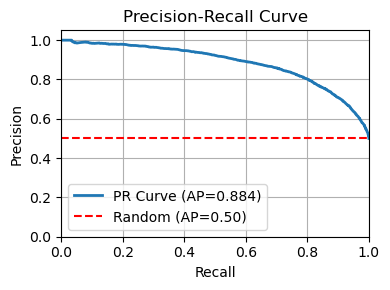

In [11]:
in_channels = 4

model = HumanLegNet(
    in_ch=in_channels,
    output_dim=1,
    stem_ch=64,
    stem_ks=11,
    ef_ks=9,
    ef_block_sizes=[32, 64, 128, 128, 256, 512, 256],
    pool_sizes=[1, 2, 1, 2, 1, 2, 1],
    resize_factor=4,
)
model.apply(initialize_weights)

seq_model = LitModel_Sahu(model=model,loss=torch.nn.BCEWithLogitsLoss(),weight_decay=1e-1,lr=1e-3,print_each=10,)

# Initialize a trainer
trainer = L.Trainer(
    accelerator="gpu",
    devices=[0],
    max_epochs=1,
    gradient_clip_val=1,
    precision="16-mixed",
    enable_progress_bar=True,
    num_sanity_val_steps=0,
    enable_model_summary=False,
)

# Train the model
trainer.fit(seq_model, train_dataloaders=train_loader, val_dataloaders=val_loader)

trainer.test(seq_model, dataloaders=test_loader)
plot_pr_auc(seq_model, trainer, test_loader)

# Genomic enhancer

In [12]:
BATCH_SIZE = 1024
NUM_WORKERS = 16
train_transform = t.Compose([t.Seq2Tensor()])
val_test_transform = t.Compose([t.Seq2Tensor()])

task = "GenomicEnhancer"

train_dataset = SahuDataset(task=task, split="train", transform=train_transform, root="../data/")
val_dataset = SahuDataset(task=task, split="val", transform=val_test_transform, root="../data/")
test_dataset = SahuDataset(task=task, split="test", transform=val_test_transform, root="../data/")

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(len(train_dataset), len(val_dataset), len(test_dataset))

323756 89062 99362


Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loading `train_dataloader` to estimate number of stepping batches.


Epoch 0: 100%|██████████| 317/317 [00:43<00:00,  7.28it/s, v_num=135, train_loss_step=0.487]

/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No negative samples in targets, false positive value should be meaningless. Returning zero tensor in false positive score
  warnings.warn(*args, **kwargs)


/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)
/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples found in target, recall is undefined. Setting recall to one for all thresholds.
  warnings.warn(*args, **kwargs)


Epoch 0: 100%|██████████| 317/317 [00:49<00:00,  6.45it/s, v_num=135, train_loss_step=0.487, val_loss=0.585, val_aupr=0.773, val_auroc=0.749, train_loss_epoch=0.557]

...

Epoch 0: 100%|██████████| 317/317 [00:50<00:00,  6.33it/s, v_num=135, train_loss_step=0.487, val_loss=0.585, val_aupr=0.773, val_auroc=0.749, train_loss_epoch=0.557]


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Testing DataLoader 0: 100%|██████████| 98/98 [00:04<00:00, 21.20it/s]
------------------------------------------------------------------------------------------------------
| Test Acc: 0.6824339032173157 | Test AUROC: 0.7359044551849365 | Test AUPR: 0.749374270439148 |
| Test Precision: 0.7915825247764587 | Test Recall: 0.43775495886802673 | Test F1: 0.5637494921684265 
------------------------------------------------------------------------------------------------------

Testing DataLoader 0: 100%|██████████| 98/98 [00:04<00:00, 21.16it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_aupr            0.749374270439148
       test_auroc           0.7359044551849365
        test_loss           0.6020269989967346
──────────────────────────

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Predicting DataLoader 0: 100%|██████████| 98/98 [00:03<00:00, 24.75it/s]
Class distribution: (array([0., 1.], dtype=float32), array([52788, 46574]))
Score range after sigmoid: [0.098, 0.997]


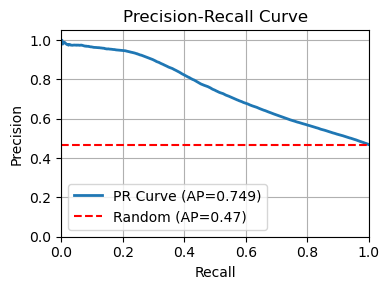

In [14]:
in_channels = 4

model = HumanLegNet(
    in_ch=in_channels,
    output_dim=1,
    stem_ch=64,
    stem_ks=11,
    ef_ks=9,
    ef_block_sizes=[32, 64, 128, 128, 256, 512, 256],
    pool_sizes=[1, 2, 1, 2, 1, 2, 1],
    resize_factor=4,
)
model.apply(initialize_weights)

seq_model = LitModel_Sahu(model=model,loss=torch.nn.BCEWithLogitsLoss(),weight_decay=1e-1,lr=1e-3,print_each=10,)

# Initialize a trainer
trainer = L.Trainer(
    accelerator="gpu",
    devices=[0],
    max_epochs=1,
    gradient_clip_val=1,
    precision="16-mixed",
    enable_progress_bar=True,
    num_sanity_val_steps=0,
    enable_model_summary=False,
)

# Train the model
trainer.fit(seq_model, train_dataloaders=train_loader, val_dataloaders=val_loader)

trainer.test(seq_model, dataloaders=test_loader)
plot_pr_auc(seq_model, trainer, test_loader)

# ATACseq

In [15]:
BATCH_SIZE = 2048
NUM_WORKERS = 16
train_transform = t.Compose([t.Seq2Tensor()])
val_test_transform = t.Compose([t.Seq2Tensor()])

task = "atacseq"

train_dataset = SahuDataset(task=task, split="train", transform=train_transform, root="../data/")
val_dataset = SahuDataset(task=task, split="val", transform=val_test_transform, root="../data/")
test_dataset = SahuDataset(task=task, split="test", transform=val_test_transform, root="../data/")

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(len(train_dataset), len(val_dataset), len(test_dataset))

2712578 910186 912794


Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loading `train_dataloader` to estimate number of stepping batches.


Epoch 0: 100%|██████████| 1325/1325 [06:15<00:00,  3.53it/s, v_num=136, train_loss_step=0.305]

/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No negative samples in targets, false positive value should be meaningless. Returning zero tensor in false positive score
  warnings.warn(*args, **kwargs)


/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)
/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples found in target, recall is undefined. Setting recall to one for all thresholds.
  warnings.warn(*args, **kwargs)



--------------------------------------------------------------------------------------------------------
| Epoch: 0 | Val Acc: 0.8132821321487427 | Val AUROC: 0.8959993124008179 | Val AUPR: 0.913085401058197 |
| Val Precision: 0.8977346420288086 | Val Recall: 0.7071642875671387 | Val F1: 0.7911350131034851 
--------------------------------------------------------------------------------------------------------

Epoch 0: 100%|██████████| 1325/1325 [07:01<00:00,  3.14it/s, v_num=136, train_loss_step=0.305, val_loss=0.415, val_aupr=0.913, val_auroc=0.896, train_loss_epoch=0.367]

...

Epoch 0: 100%|██████████| 1325/1325 [07:02<00:00,  3.14it/s, v_num=136, train_loss_step=0.305, val_loss=0.415, val_aupr=0.913, val_auroc=0.896, train_loss_epoch=0.367]


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Testing DataLoader 0: 100%|██████████| 446/446 [00:41<00:00, 10.73it/s]
-----------------------------------------------------------------------------------------------------
| Test Acc: 0.795303225517273 | Test AUROC: 0.87857985496521 | Test AUPR: 0.9022716879844666 |
| Test Precision: 0.8818522691726685 | Test Recall: 0.6951586008071899 | Test F1: 0.7774546146392822 
-----------------------------------------------------------------------------------------------------

Testing DataLoader 0: 100%|██████████| 446/446 [00:41<00:00, 10.72it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_aupr           0.9022716879844666
       test_auroc            0.87857985496521
        test_loss           0.44984298944473267
───────────────────────────

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Predicting DataLoader 0: 100%|██████████| 446/446 [00:35<00:00, 12.61it/s]
Class distribution: (array([0., 1.], dtype=float32), array([443304, 469490]))
Score range after sigmoid: [0.002, 0.999]


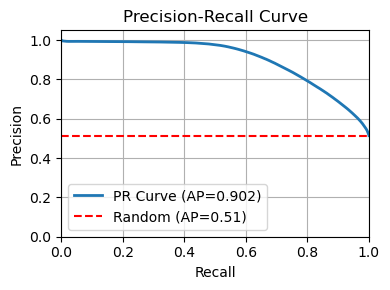

In [16]:
in_channels = 4

model = HumanLegNet(
    in_ch=in_channels,
    output_dim=1,
    stem_ch=64,
    stem_ks=11,
    ef_ks=9,
    ef_block_sizes=[32, 64, 128, 128, 256, 512, 256],
    pool_sizes=[1, 2, 1, 2, 1, 2, 1],
    resize_factor=4,
)
model.apply(initialize_weights)

seq_model = LitModel_Sahu(model=model,loss=torch.nn.BCEWithLogitsLoss(),weight_decay=1e-1,lr=1e-3,print_each=1,)

# Initialize a trainer
trainer = L.Trainer(
    accelerator="gpu",
    devices=[0],
    max_epochs=1,
    gradient_clip_val=1,
    precision="16-mixed",
    enable_progress_bar=True,
    num_sanity_val_steps=0,
    enable_model_summary=False,
)

# Train the model
trainer.fit(seq_model, train_dataloaders=train_loader, val_dataloaders=val_loader)

trainer.test(seq_model, dataloaders=test_loader)
plot_pr_auc(seq_model, trainer, test_loader)

# Binary task

In [17]:
class HumanLegNetBinary(HumanLegNet):
    def __init__(
        self,
    ):
        super().__init__(
            in_ch=4,
            output_dim=1,
            stem_ch=64,
            stem_ks=11,
            ef_ks=9,
            ef_block_sizes=[80, 96, 112, 128],
            pool_sizes=[2, 2, 2, 2],
            resize_factor=4,
            activation=nn.SiLU,
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.main(x)
        x = self.mapper(x)
        x = F.adaptive_avg_pool1d(x, 1)
        x = x.squeeze(-1)  # without head
        # x = self.head(x)
        # x = x.squeeze(-1)
        # head will be used in trainer because paired task has paired sequences
        return x

In [18]:
BATCH_SIZE = 1024
NUM_WORKERS = 16

train_transform = t.Compose([t.Seq2Tensor(),])
val_test_transform = t.Compose([t.Seq2Tensor()])

binary_train = [None, "promoter_from_input", "enhancer_permutated", "enhancer_from_input"]
task = "binary"

train_dataset = SahuDataset(task=task,binary_class=None,split="train",transform=train_transform,root="../data/",)
val_dataset = SahuDataset(task=task, split="val", transform=val_test_transform, root="../data/")
test_dataset = SahuDataset(task=task, split="test", transform=val_test_transform, root="../data/")

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(len(train_dataset), len(val_dataset), len(test_dataset))

using train
using val
using test
2991302 748828 1252044


Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loading `train_dataloader` to estimate number of stepping batches.


Epoch 0: 100%|██████████| 2922/2922 [04:14<00:00, 11.46it/s, v_num=137, train_loss_step=0.457]

/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No negative samples in targets, false positive value should be meaningless. Returning zero tensor in false positive score
  warnings.warn(*args, **kwargs)


/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)
/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples found in target, recall is undefined. Setting recall to one for all thresholds.
  warnings.warn(*args, **kwargs)



---------------------------------------------------------------------------------------------------------
| Epoch: 0 | Val Acc: 0.7713212966918945 | Val AUROC: 0.8460342884063721 | Val AUPR: 0.8554742336273193 |
| Val Precision: 0.776652455329895 | Val Recall: 0.7616862654685974 | Val F1: 0.7690965533256531 
---------------------------------------------------------------------------------------------------------

Epoch 0: 100%|██████████| 2922/2922 [04:56<00:00,  9.85it/s, v_num=137, train_loss_step=0.457, val_loss=0.487, val_aupr=0.855, val_auroc=0.846, train_loss_epoch=0.519]

...

Epoch 0: 100%|██████████| 2922/2922 [04:56<00:00,  9.84it/s, v_num=137, train_loss_step=0.457, val_loss=0.487, val_aupr=0.855, val_auroc=0.846, train_loss_epoch=0.519]


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Testing DataLoader 0: 100%|██████████| 1223/1223 [01:25<00:00, 14.36it/s]
-----------------------------------------------------------------------------------------------------
| Test Acc: 0.7707780003547668 | Test AUROC: 0.8457708358764648 | Test AUPR: 0.8552985191345215 |
| Test Precision: 0.7761526703834534 | Test Recall: 0.7610467076301575 | Test F1: 0.7685254812240601 
-----------------------------------------------------------------------------------------------------

Testing DataLoader 0: 100%|██████████| 1223/1223 [01:25<00:00, 14.36it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_aupr           0.8552985191345215
       test_auroc           0.8457708358764648
        test_loss           0.4877616763114929
────────────────────

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Predicting DataLoader 0: 100%|██████████| 1223/1223 [00:31<00:00, 38.91it/s]
Class distribution: (array([0., 1.], dtype=float32), array([626022, 626022]))
Score range after sigmoid: [0.009, 1.000]


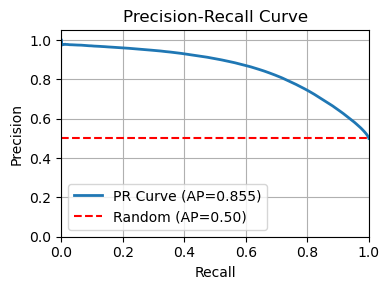

In [19]:
model = HumanLegNetBinary()
model.apply(initialize_weights)

seq_model = LitModel_Sahu_binary_legnet(model=model,loss=torch.nn.BCEWithLogitsLoss(),weight_decay=1e-1,lr=1e-3,print_each=1,)

# Initialize a trainer
trainer = L.Trainer(
    accelerator="gpu",
    devices=[0],
    max_epochs=1,
    gradient_clip_val=1,
    precision="16-mixed",
    enable_progress_bar=True,
    num_sanity_val_steps=0,
    enable_model_summary=False,
)

# Train the model
trainer.fit(seq_model, train_dataloaders=train_loader, val_dataloaders=val_loader)

trainer.test(seq_model, dataloaders=test_loader)
plot_pr_auc(seq_model, trainer, test_loader)